# Battery Current Time Series Prediction

## Import Library

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

2026-02-28 19:24:26.337715: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-28 19:24:26.377022: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-28 19:24:27.426229: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Load Dataset

In [2]:
df = pd.read_csv('~/AndroidMonitoring/Clustering/data/dataset/dataset.csv')
df.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_drain,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness
0,2026-02-28 12:50:59,62,67,34.6,78,-111.0,0,0.000000,0.00000,1,29
1,2026-02-28 12:51:03,32,70,34.6,78,-919.0,0,26.884218,192.38039,1,29
2,2026-02-28 12:51:07,48,69,34.6,78,-383.0,0,12.268097,520.40784,1,29
3,2026-02-28 12:51:11,35,68,34.6,78,-193.0,0,7.023991,524.93000,1,29
4,2026-02-28 12:51:15,46,69,34.6,78,-804.0,0,13.961425,396.78143,1,29


In [3]:
df.describe()

,cpu_usage,memory_usage,temperature,battery_level,battery_drain,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness
count,3423.000000,3423.000000,3423.000000,3423.000000,3423.000000,3423.0,3423.000000,3423.000000,3423.000000,3423.000000
mean,49.287759,74.572013,34.881770,47.049956,-332.404908,0.0,5.056843,81.529300,0.969325,25.799591
std,15.782952,3.649376,1.697165,17.314673,174.798104,0.0,10.513964,220.516434,0.172460,3.487664
min,24.000000,63.000000,30.800000,18.000000,-1369.000000,0.0,0.000000,0.000000,0.000000,22.000000
25%,36.000000,72.000000,34.100000,33.000000,-399.500000,0.0,0.421486,0.086403,1.000000,22.000000
50%,45.000000,74.000000,34.900000,47.000000,-284.000000,0.0,1.540133,2.265015,1.000000,29.000000
75%,57.000000,77.000000,35.600000,62.000000,-220.000000,0.0,5.199030,69.691555,1.000000,29.000000
max,100.000000,85.000000,39.200000,78.000000,-12.000000,0.0,183.420440,3450.904500,1.000000,29.000000


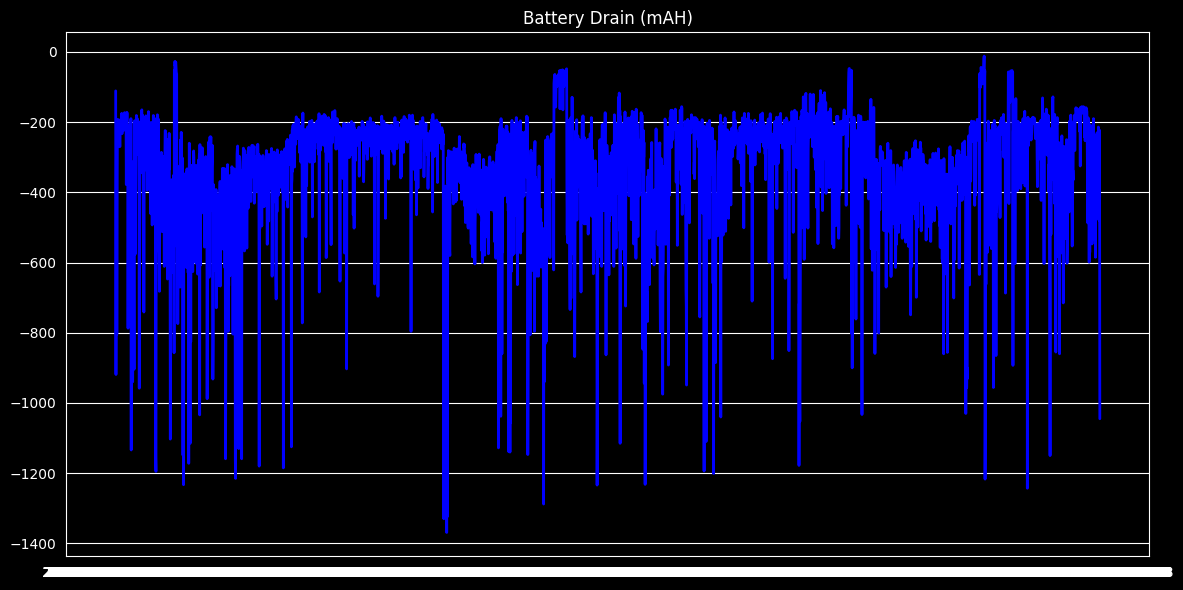

In [4]:
plt.figure(figsize=(12,6))
plt.plot(df['timestamp'], df["battery_drain"], color="blue", linewidth=2)
plt.title("Battery Drain (mAH)")
plt.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

## Training

### Data Preparation

In [5]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

features_scaled = feature_scaler.fit_transform(
    df.drop(columns=['timestamp','temperature', 'battery_drain','battery_charging'])
)

target_scaled = target_scaler.fit_transform(
    df[['battery_drain']]
)

In [6]:
scaler_param = {
    "mean": feature_scaler.mean_.tolist(),
    "scale": feature_scaler.scale_.tolist(),
}

json_dir = os.path.expanduser(
    "~/AndroidMonitoring/TimeSeries/data/param/param.json")
os.makedirs(os.path.dirname(json_dir), exist_ok=True)

with open(json_dir, 'w') as outfile:
    json.dump(scaler_param, outfile)

In [7]:
features = features_scaled
target = target_scaled.flatten()
window_size = 150
horizon = 15
X = []
y = []

for i in range(len(features) - window_size - horizon):
    X.append(features[i:i+window_size])
    y.append(target[i+window_size:i+window_size+horizon])

X = np.array(X)
y = np.array(y)

print("Feature Shape: ", X.shape)
print("Label Shape: ", y.shape)

Feature Shape:  (3258, 150, 7)
Label Shape:  (3258, 15)


### Data Splitting

In [8]:
train = int(len(X) * 0.6)
val = int(len(X) * 0.8)

X_train, y_train = X[:train], y[:train]
X_val, y_val = X[train:val], y[train:val]
X_test, y_test = X[val:], y[val:]

print("Train Shape: ", X_train.shape)
print("Validation Shape: ", X_val.shape)
print("Test Shape: ", X_test.shape)

Train Shape:  (1954, 150, 7)
Validation Shape:  (652, 150, 7)
Test Shape:  (652, 150, 7)


### Model Architecture

In [9]:
model = Sequential([
    LSTM(8, return_sequences=True,
         input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(4),
    Dense(15)
])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.compile(optimizer='adam', loss='mse')
model.summary()

E0000 00:00:1772281480.482782   77383 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772281480.492304   77383 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/abel-putra/AndroidMonitoring/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 150, 8)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 4)              │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │            75 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 795 (3.11 KB)

 Trainable params: 795 (3.11 KB)

 Non-trainable params: 0 (0.00 B)

### Start Train

In [10]:
model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 1.0632 - val_loss: 0.7225
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.0057 - val_loss: 0.7106
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.9596 - val_loss: 0.6862
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.9218 - val_loss: 0.6800
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.8979 - val_loss: 0.7004
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.8828 - val_loss: 0.7189
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.8716 - val_loss: 0.7485
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.8637 - val_loss: 0.7705
Epoch 9/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.8566 - val_loss: 0.8029


## Evaluation

In [11]:
pred = model.predict(X_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [12]:
mae = mean_absolute_error(
    y_test.reshape(-1),
    pred.reshape(-1)
)

print("MAE:", mae)

MAE: 0.6746460520523062


In [13]:
pred_real = target_scaler.inverse_transform(pred)
y_test_real = target_scaler.inverse_transform(y_test)

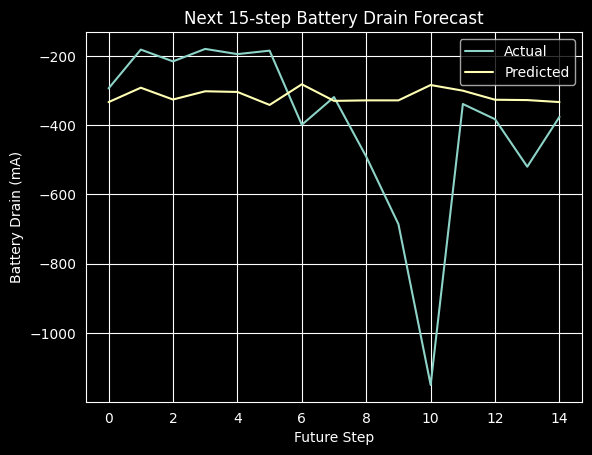

In [14]:
idx = np.random.randint(0, len(y_test_real))
plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_real[idx], label="Predicted")
plt.title("Next 15-step Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()